# MP3000A Radiometer Data Visualization

Comprehensive analysis of K-band (22-30 GHz) brightness temperature observations from the MP3000A radiometer.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load the cleaned data
# data_file = Path("../data/datos_radiometro_procesados/2023-04-09.csv")
# Use below line if from synthetic data
data_file = Path("../data/datos_radiometro_sinteticos/synthetic_004.csv")
data = np.genfromtxt(data_file, delimiter=",", skip_header=1)

# Read header to get frequency information
with open(data_file) as f:
    header = f.readline().strip().split(",")

# Extract frequencies (GHz) - find columns starting with "Ch"
freq_cols = [h for h in header if h.startswith("Ch")]
frequencies = np.array([float(col.split()[1]) for col in freq_cols])

# Find the index where frequency columns start
freq_start_idx = next(i for i, h in enumerate(header) if h.startswith("Ch"))

# Extract TB data (only frequency columns)
tb_data = data[:, freq_start_idx:freq_start_idx + len(frequencies)]
az_data = data[:, 1]  # Az(deg) is typically column 1
el_data = data[:, 2]  # El(deg) is typically column 2

print(f"✅ Loaded {len(tb_data)} observations")
print(f"   Frequency range: {frequencies[0]:.3f} - {frequencies[-1]:.3f} GHz")
print(f"   {len(frequencies)} channels")
print(f"   TB range: {tb_data.min():.1f} - {tb_data.max():.1f} K")
print(f"   Elevation angles: {el_data.min():.1f} - {el_data.max():.1f}°")

✅ Loaded 2838 observations
   Frequency range: 22.000 - 30.000 GHz
   21 channels
   TB range: 16.9 - 261.0 K
   Elevation angles: 51.0 - 51.0°


## Mean Spectrum with Uncertainty

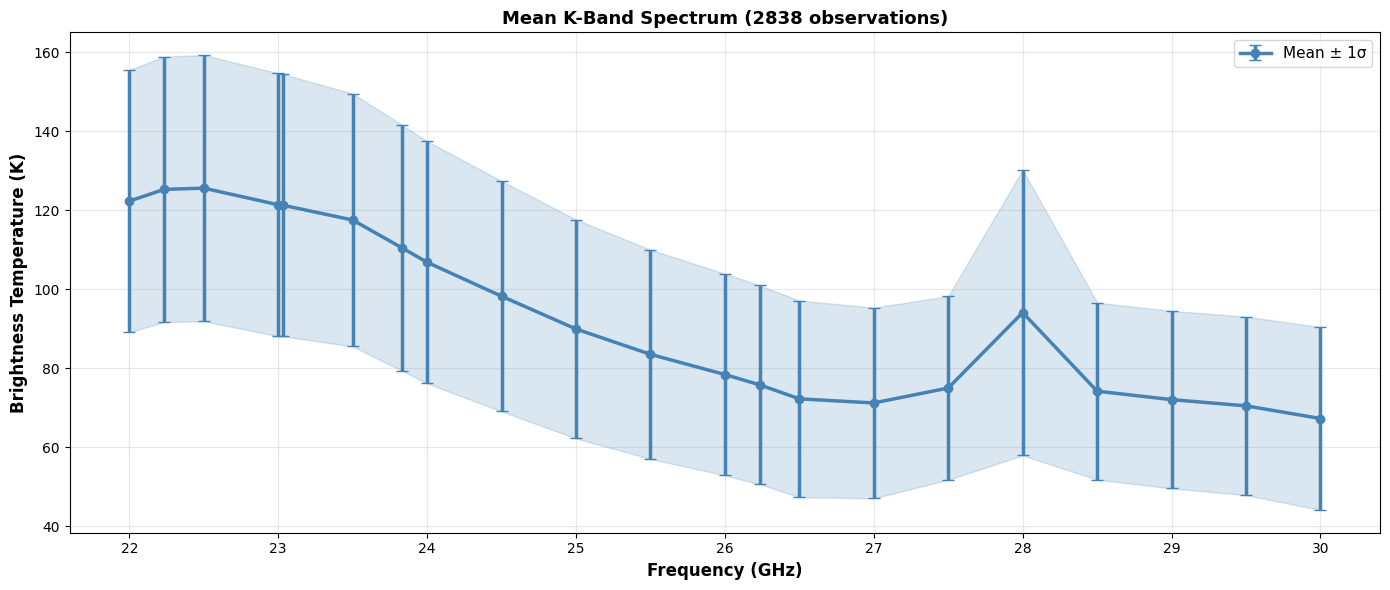

In [49]:
fig, ax = plt.subplots(figsize=(14, 6))

mean_tb = np.mean(tb_data, axis=0)
std_tb = np.std(tb_data, axis=0)

ax.errorbar(frequencies, mean_tb, yerr=std_tb, fmt="o-", linewidth=2.5, markersize=6, 
            capsize=4, label="Mean ± 1σ", color="steelblue")
ax.fill_between(frequencies, mean_tb - std_tb, mean_tb + std_tb, 
                alpha=0.2, color="steelblue")

ax.set_xlabel("Frequency (GHz)", fontsize=12, fontweight="bold")
ax.set_ylabel("Brightness Temperature (K)", fontsize=12, fontweight="bold")
ax.set_title(f"Mean K-Band Spectrum ({len(tb_data)} observations)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## All Records Spectrum

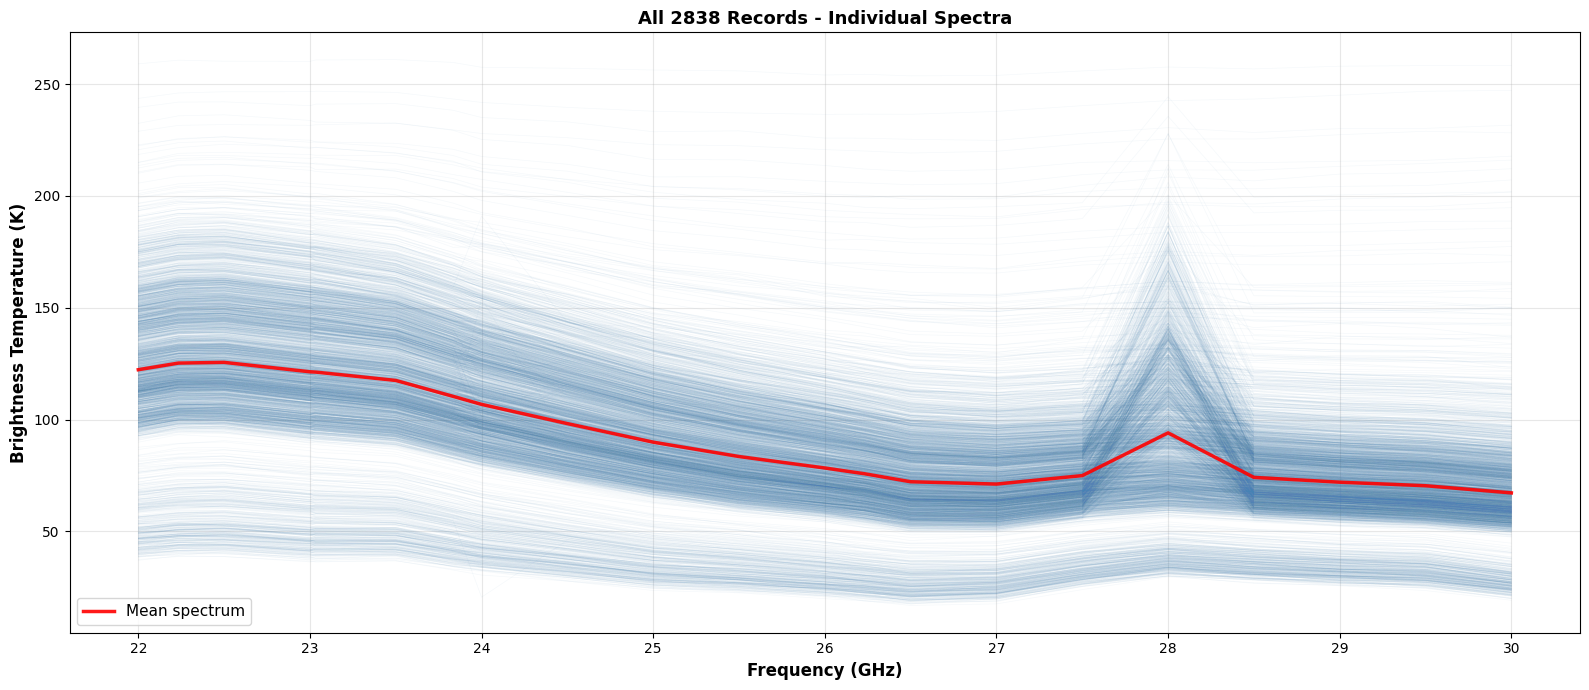

✅ Plotted 2838 individual records
   Each record is a faint blue line with alpha=0.05


In [50]:
fig, ax = plt.subplots(figsize=(16, 7))

# Plot every single record as a thin semi-transparent line
for i in range(len(tb_data)):
    ax.plot(frequencies, tb_data[i], color="steelblue", alpha=0.05, linewidth=0.5)

# Overlay the mean spectrum in bold for reference
ax.plot(frequencies, mean_tb, color="red", linewidth=2.5, label="Mean spectrum", alpha=0.9)

ax.set_xlabel("Frequency (GHz)", fontsize=12, fontweight="bold")
ax.set_ylabel("Brightness Temperature (K)", fontsize=12, fontweight="bold")
ax.set_title(f"All {len(tb_data)} Records - Individual Spectra", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"✅ Plotted {len(tb_data)} individual records")
print(f"   Each record is a faint blue line with alpha=0.05")

## Brightness Temperature Heatmap

NameError: name 'datetimes' is not defined

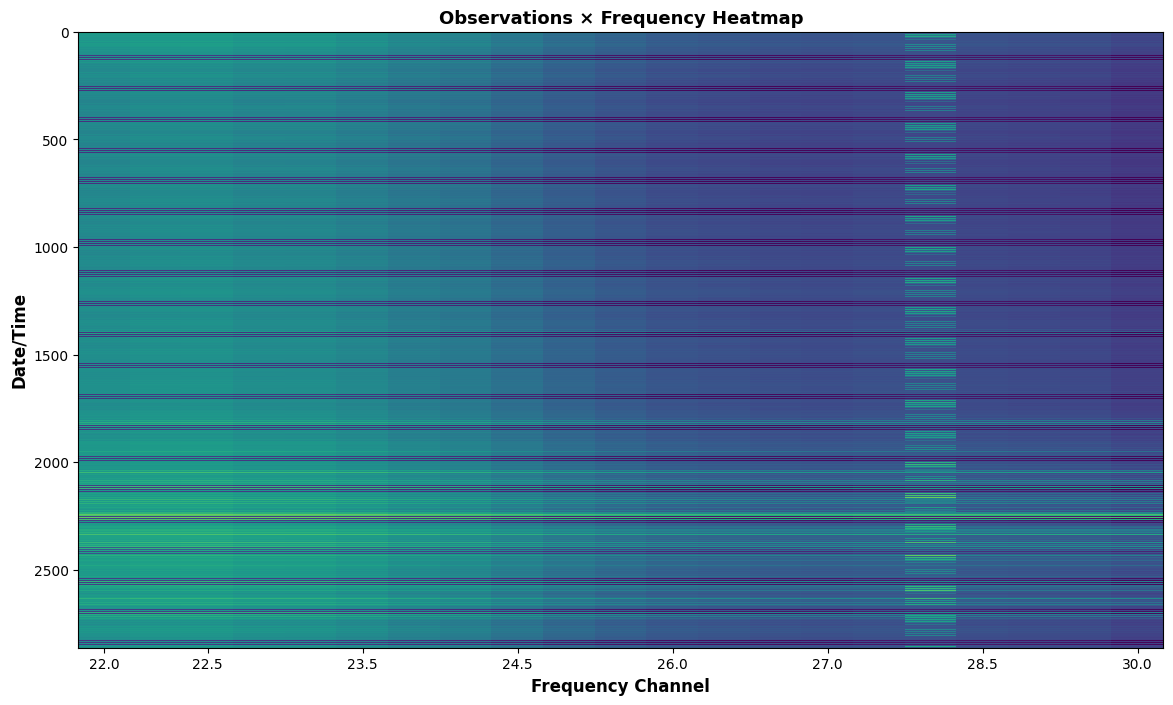

In [28]:
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(tb_data, aspect="auto", cmap="viridis", interpolation="nearest")

ax.set_xlabel("Frequency Channel", fontsize=12, fontweight="bold")
ax.set_ylabel("Date/Time", fontsize=12, fontweight="bold")
ax.set_title("Observations × Frequency Heatmap", fontsize=13, fontweight="bold")

# Add frequency labels on x-axis
x_ticks = np.linspace(0, len(frequencies)-1, 8, dtype=int)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{frequencies[i]:.1f}" for i in x_ticks])

# Add Date/Time labels on y-axis (show every nth one to avoid crowding)
step = max(1, len(datetimes) // 10)
y_positions = np.arange(0, len(datetimes), step)
ax.set_yticks(y_positions)
ax.set_yticklabels([datetimes[i] for i in y_positions], fontsize=9)

cbar = plt.colorbar(im, ax=ax, label="TB (K)")

plt.tight_layout()
plt.show()

## Statistical Analysis

NameError: name 'datetimes' is not defined

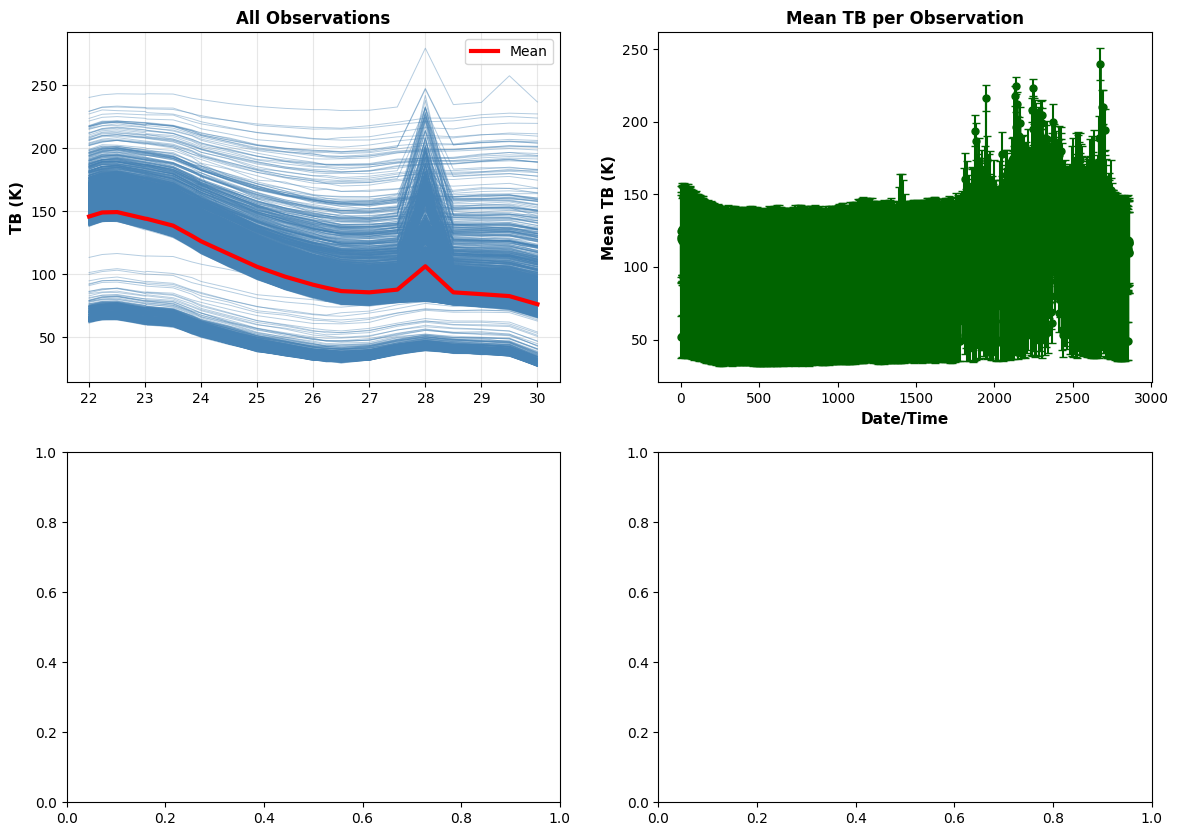

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Individual spectra
ax = axes[0, 0]
for i in range(len(tb_data)):
    ax.plot(frequencies, tb_data[i], alpha=0.4, linewidth=0.7, color="steelblue")
ax.plot(frequencies, mean_tb, "r-", linewidth=3, label="Mean", zorder=10)
ax.set_ylabel("TB (K)", fontsize=11, fontweight="bold")
ax.set_title("All Observations", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. TB per observation (mean) - with Date/Time
ax = axes[0, 1]
obs_means = np.mean(tb_data, axis=1)
obs_stds = np.std(tb_data, axis=1)
ax.errorbar(range(len(obs_means)), obs_means, yerr=obs_stds, fmt="o-", 
            markersize=5, capsize=3, linewidth=1.5, color="darkgreen")
ax.set_xlabel("Date/Time", fontsize=11, fontweight="bold")
ax.set_ylabel("Mean TB (K)", fontsize=11, fontweight="bold")
ax.set_title("Mean TB per Observation", fontsize=12, fontweight="bold")

# Add Date/Time labels (show every nth one to avoid crowding)
step = max(1, len(datetimes) // 8)
x_positions = range(0, len(datetimes), step)
ax.set_xticks(x_positions)
ax.set_xticklabels([datetimes[i] for i in x_positions], rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3)

# 3. Min/Mean/Max per channel
ax = axes[1, 0]
min_tb = np.min(tb_data, axis=0)
max_tb = np.max(tb_data, axis=0)
ax.plot(frequencies, min_tb, "b--", linewidth=1.5, label="Min", alpha=0.7)
ax.plot(frequencies, mean_tb, "g-", linewidth=2.5, label="Mean")
ax.plot(frequencies, max_tb, "r--", linewidth=1.5, label="Max", alpha=0.7)
ax.fill_between(frequencies, min_tb, max_tb, alpha=0.15, color="gray")
ax.set_xlabel("Frequency (GHz)", fontsize=11, fontweight="bold")
ax.set_ylabel("TB (K)", fontsize=11, fontweight="bold")
ax.set_title("Range per Channel", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 4. TB distribution
ax = axes[1, 1]
ax.hist(tb_data.flatten(), bins=50, color="purple", alpha=0.7, edgecolor="black")
ax.axvline(np.mean(tb_data), color="red", linestyle="--", linewidth=2, label=f"Mean: {np.mean(tb_data):.1f} K")
ax.set_xlabel("Brightness Temperature (K)", fontsize=11, fontweight="bold")
ax.set_ylabel("Count", fontsize=11, fontweight="bold")
ax.set_title("TB Distribution", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"K-Band Radiometer Analysis ({len(tb_data)} observations × {len(frequencies)} channels)", 
             fontsize=13, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

## Elevation Angle Analysis

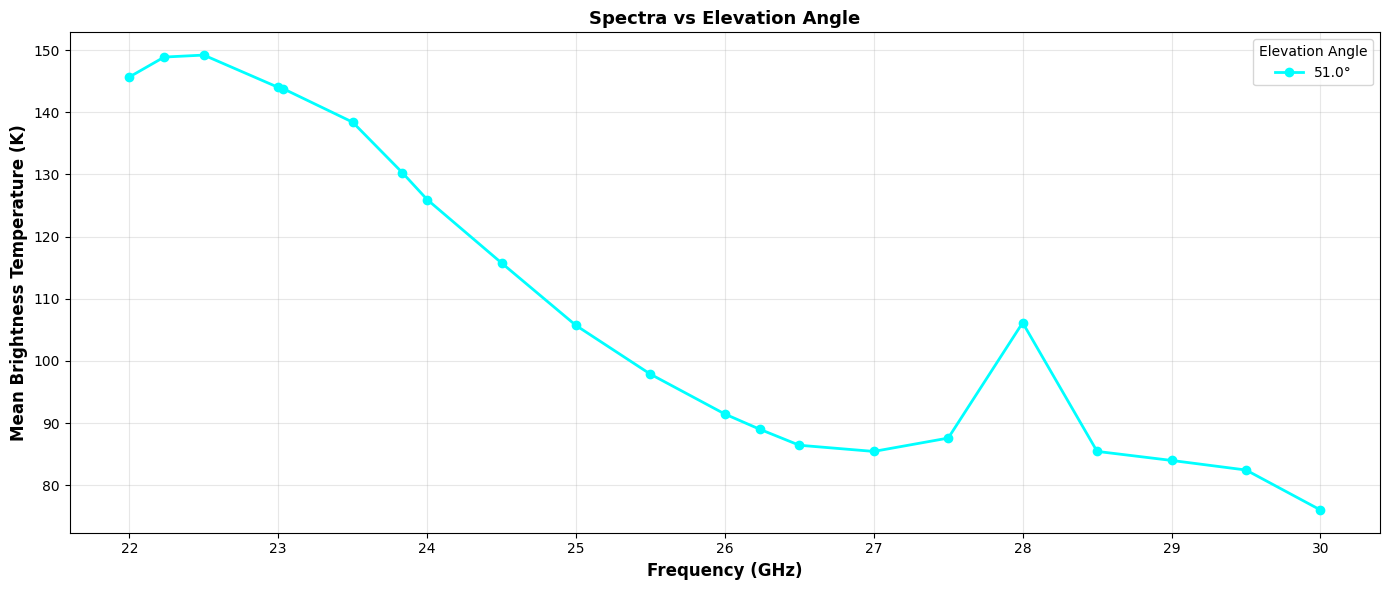


📊 Statistics by Elevation Angle:
   El =   51.0°: 2862 obs, Mean TB =  110.5 K, Std =  37.9 K


In [30]:
# Group observations by elevation angle
unique_els = np.unique(el_data)
colors = plt.cm.cool(np.linspace(0, 1, len(unique_els)))

fig, ax = plt.subplots(figsize=(14, 6))

for el, color in zip(unique_els, colors):
    mask = el_data == el
    el_mean = np.mean(tb_data[mask], axis=0)
    ax.plot(frequencies, el_mean, marker="o", linewidth=2, markersize=6, 
            label=f"{el:.1f}°", color=color)

ax.set_xlabel("Frequency (GHz)", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean Brightness Temperature (K)", fontsize=12, fontweight="bold")
ax.set_title("Spectra vs Elevation Angle", fontsize=13, fontweight="bold")
ax.legend(title="Elevation Angle", fontsize=10, loc="best", ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n📊 Statistics by Elevation Angle:")
for el in unique_els:
    mask = el_data == el
    mean_tb_el = np.mean(tb_data[mask])
    std_tb_el = np.std(tb_data[mask])
    n_obs = np.sum(mask)
    print(f"   El = {el:6.1f}°: {n_obs:3d} obs, Mean TB = {mean_tb_el:6.1f} K, Std = {std_tb_el:5.1f} K")

## Channel-wise Variability

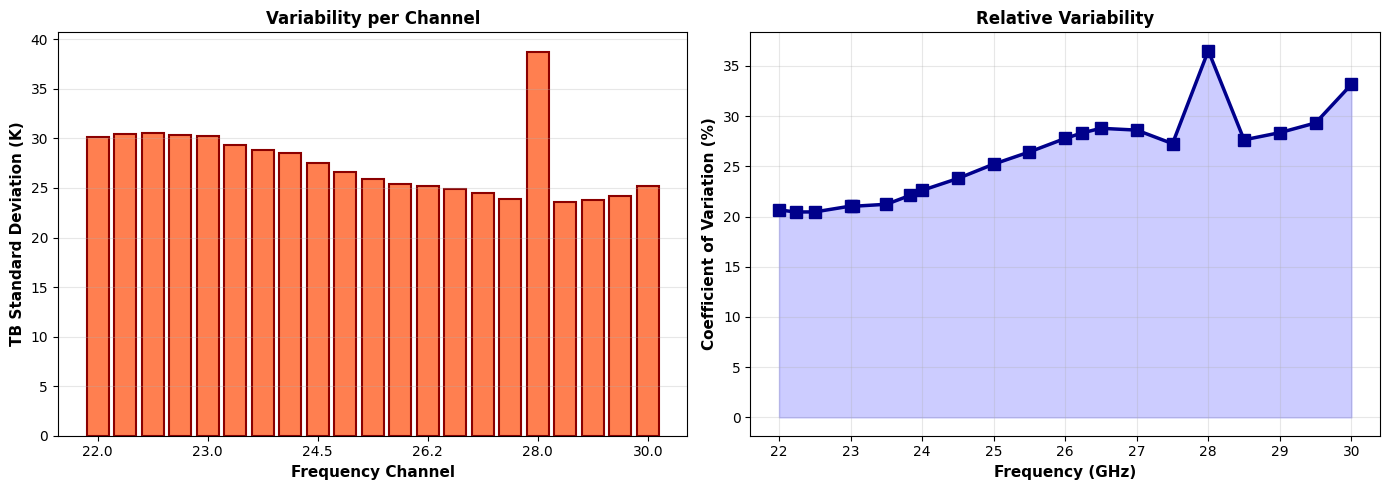


📈 Channel Statistics:
   Ch 22.000 GHz: μ =  145.7 K, σ =  30.1 K, CV =  20.7%
   Ch 22.234 GHz: μ =  148.9 K, σ =  30.5 K, CV =  20.5%
   Ch 22.500 GHz: μ =  149.2 K, σ =  30.5 K, CV =  20.5%
   Ch 23.000 GHz: μ =  144.0 K, σ =  30.3 K, CV =  21.0%
   Ch 23.034 GHz: μ =  143.8 K, σ =  30.2 K, CV =  21.0%
   Ch 23.500 GHz: μ =  138.4 K, σ =  29.4 K, CV =  21.2%
   Ch 23.834 GHz: μ =  130.3 K, σ =  28.8 K, CV =  22.1%
   Ch 24.000 GHz: μ =  126.0 K, σ =  28.5 K, CV =  22.6%
   Ch 24.500 GHz: μ =  115.8 K, σ =  27.5 K, CV =  23.8%
   Ch 25.000 GHz: μ =  105.7 K, σ =  26.7 K, CV =  25.2%
   Ch 25.500 GHz: μ =   97.9 K, σ =  25.9 K, CV =  26.4%
   Ch 26.000 GHz: μ =   91.5 K, σ =  25.4 K, CV =  27.8%
   Ch 26.234 GHz: μ =   89.0 K, σ =  25.2 K, CV =  28.3%
   Ch 26.500 GHz: μ =   86.4 K, σ =  24.9 K, CV =  28.8%
   Ch 27.000 GHz: μ =   85.4 K, σ =  24.4 K, CV =  28.6%
   Ch 27.500 GHz: μ =   87.6 K, σ =  23.9 K, CV =  27.3%
   Ch 28.000 GHz: μ =  106.2 K, σ =  38.8 K, CV =  36.5%
   Ch 28

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Standard deviation per channel
ax = axes[0]
ax.bar(range(len(frequencies)), std_tb, color="coral", edgecolor="darkred", linewidth=1.5)
ax.set_xlabel("Frequency Channel", fontsize=11, fontweight="bold")
ax.set_ylabel("TB Standard Deviation (K)", fontsize=11, fontweight="bold")
ax.set_title("Variability per Channel", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

# Add frequency labels at regular intervals
x_ticks = np.linspace(0, len(frequencies)-1, 6, dtype=int)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{frequencies[i]:.1f}" for i in x_ticks])

# 2. Coefficient of variation
ax = axes[1]
cv = std_tb / mean_tb * 100  # as percentage
ax.plot(frequencies, cv, marker="s", linewidth=2.5, markersize=8, color="darkblue")
ax.fill_between(frequencies, cv, alpha=0.2, color="blue")
ax.set_xlabel("Frequency (GHz)", fontsize=11, fontweight="bold")
ax.set_ylabel("Coefficient of Variation (%)", fontsize=11, fontweight="bold")
ax.set_title("Relative Variability", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print channel statistics
print("\n📈 Channel Statistics:")
for i, freq in enumerate(frequencies):
    print(f"   Ch {freq:6.3f} GHz: μ = {mean_tb[i]:6.1f} K, σ = {std_tb[i]:5.1f} K, CV = {cv[i]:5.1f}%")